# Self-Evolving Reinforcement Learning for ANDM-Inspired SDN
## Final Measured ONOS–Mininet Experiment

## Imports

In [1]:
from importlib.metadata import version  # Reads installed package versions.
from pathlib import Path  # Manages project files and folders.
import hashlib  # Calculates SHA-256 evidence hashes.
import json  # Saves experiment settings in a readable format.
import random  # Controls Python random choices.
import time  # Measures model training time.
import warnings  # Controls non-critical warning messages.

import numpy as np  # Performs numerical calculations.
import pandas as pd  # Loads, checks and combines the CSV datasets.
import matplotlib.pyplot as plt  # Creates the research graphs.
import seaborn as sns  # Applies clear graph styling.
from IPython.display import display  # Shows tables neatly in the notebook.

import gymnasium as gym  # Provides the reinforcement-learning environment structure.
from gymnasium import spaces  # Defines the allowed states and actions.
from river import drift  # Provides the ADWIN concept-drift detector.
from stable_baselines3 import DQN, PPO  # Provides the two RL agents being compared.
from stable_baselines3.common.env_checker import check_env  # Checks the custom environment.
import torch  # Controls the neural-network calculation settings.

# Record the software versions used by this notebook.
PACKAGE_VERSIONS = {
    "python": __import__("sys").version.split()[0],
    "numpy": version("numpy"),
    "pandas": version("pandas"),
    "matplotlib": version("matplotlib"),
    "gymnasium": version("gymnasium"),
    "stable_baselines3": version("stable-baselines3"),
    "river": version("river"),
    "torch": version("torch"),
}

display(pd.Series(PACKAGE_VERSIONS, name="version").to_frame())

,version
python,3.14.7
numpy,2.5.1
pandas,3.0.3
matplotlib,3.11.0
gymnasium,1.3.0
stable_baselines3,2.9.0
river,0.26.1
torch,2.13.0


## Experiment Settings

In [2]:
# Keep all warnings available except repeated library notices.
warnings.filterwarnings("ignore", category=FutureWarning)

# Use the completed research settings instead of a short practice run.
FINAL_MODE = True

# Use matching seeds so DQN and PPO receive the same comparison conditions.
TRAINING_SEEDS = [7, 17, 29, 42, 61, 73, 89, 101, 127, 149]

# Use several evaluation offsets without changing the measured rows.
EVALUATION_SEEDS = list(range(501, 516))

# Set the training budgets used by both agents.
TRAIN_TIMESTEPS = 15_000 if FINAL_MODE else 3_000
ADAPT_TIMESTEPS = 12_000 if FINAL_MODE else 2_000
BOOTSTRAP_SAMPLES = 10_000 if FINAL_MODE else 1_000

# Load completed models during a later demonstration instead of training again.
RESUME_MODELS = True

# Define the simulated vCPU decision limits.
MIN_VCPU = 1
MAX_VCPU = 4
INITIAL_VCPU = 2
REFERENCE_VCPU = 2.0
CPU_TARGET_PERCENT = 70.0

# Preserve the required order of the simulated daily periods.
PHASES = ["Morning", "Afternoon", "Night"]
PHASE_TICKS = [29.5, 89.5, 149.5]
PHASE_COLOURS = {"Morning": "#f59e0b", "Afternoon": "#dc2626", "Night": "#1d4ed8"}

# Use one CPU thread because the experiment runs on a four-vCPU computer.
torch.set_num_threads(1)

# Make repeated runs use the same software randomness.
random.seed(2026)
np.random.seed(2026)
torch.manual_seed(2026)

# Create the folders used by the notebook.
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
EVIDENCE_DIR = PROJECT_DIR / "evidence"
OUTPUT_DIR = PROJECT_DIR / "rl_outputs"
MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Apply one visual style to every graph.
sns.set_theme(style="whitegrid", context="notebook")

print(f"Final mode: {FINAL_MODE}")
print(f"Training seeds per agent: {len(TRAINING_SEEDS)}")
print(f"Training timesteps per seed: {TRAIN_TIMESTEPS:,}")
print(f"Project folder: {PROJECT_DIR}")
print("Evidence boundary: controlled ANDM-inspired testbed, not operational ANDM telemetry.")

Final mode: True
Training seeds per agent: 10
Training timesteps per seed: 15,000
Project folder: C:\Users\Athenkosi Nqumako\OneDrive - University of Fort Hare\Desktop\Honours\Research\Mini-Dissertation\RL_Training\ANDM_Final_Measured_RL_Package
Evidence boundary: controlled ANDM-inspired testbed, not operational ANDM telemetry.


## Evidence Paths

In [3]:
# Point to the four final measured datasets.
SOURCE_FILES = {
    "baseline_cpu": DATA_DIR / "mininet_baseline_cpu.csv",
    "baseline_network": DATA_DIR / "mininet_baseline_network_raw.csv",
    "rural_cpu": DATA_DIR / "mininet_rural_cpu.csv",
    "rural_network": DATA_DIR / "mininet_rural_network_raw.csv",
    "generator": EVIDENCE_DIR / "andm_mininet_capture_final_v5.py",
}

# Store the hashes recorded immediately after the Mininet experiment.
EXPECTED_HASHES = {
    "mininet_baseline_cpu.csv": "7d44065414cb807fbe1454b0ae1b63100ebdc30afa04f9ea850400a02171b53b",
    "mininet_baseline_network_raw.csv": "408bdfabd3637f544e0147f67c0fc9e6fe3d338f3a8d382f41d7158504ef250f",
    "mininet_rural_cpu.csv": "8bf6e38e7afb5a598b2b836aa0a735412a34d8a09b1d5e9e54912ee5c42b1d06",
    "mininet_rural_network_raw.csv": "a54763281c1df9c41281076db821db34a624716cb5f656bfcf40a46e2200f110",
    "andm_mininet_capture_final_v5.py": "9bf8f14d3c63731b0e680873b652ae5cf8a6dcee76bced56a33ec86872367d57",
}

# Stop immediately when any required file is missing.
for label, path in SOURCE_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing evidence file: {path}")
    print(f"{label}: {path.relative_to(PROJECT_DIR)}")

baseline_cpu: data\mininet_baseline_cpu.csv
baseline_network: data\mininet_baseline_network_raw.csv
rural_cpu: data\mininet_rural_cpu.csv
rural_network: data\mininet_rural_network_raw.csv
generator: evidence\andm_mininet_capture_final_v5.py


## SHA-256 Verification

In [4]:
# Calculate one SHA-256 value without changing the file.
def calculate_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# Compare every uploaded file with the value recorded in Ubuntu.
hash_rows = []
for path in SOURCE_FILES.values():
    actual_hash = calculate_sha256(path)
    expected_hash = EXPECTED_HASHES[path.name]
    hash_rows.append(
        {
            "file": path.name,
            "expected_sha256": expected_hash,
            "actual_sha256": actual_hash,
            "status": "PASS" if actual_hash == expected_hash else "FAIL",
        }
    )

# Reject the experiment if any file changed after capture.
hash_audit = pd.DataFrame(hash_rows)
display(hash_audit[["file", "status"]])
if not (hash_audit["status"] == "PASS").all():
    raise ValueError("Evidence verification failed.")

print("All evidence hashes match the Ubuntu record.")

,file,status
0,mininet_baseline_cpu.csv,PASS
1,mininet_baseline_network_raw.csv,PASS
2,mininet_rural_cpu.csv,PASS
3,mininet_rural_network_raw.csv,PASS
4,andm_mininet_capture_final_v5.py,PASS


All evidence hashes match the Ubuntu record.


## Load the Four Measured Datasets

In [5]:
# Load one CPU file and convert its timestamp to a real date-time value.
def load_cpu_file(path):
    frame = pd.read_csv(path)
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], errors="raise")
    return frame


# Load one network file and convert its timestamp to a real date-time value.
def load_network_file(path):
    frame = pd.read_csv(path)
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], errors="raise")
    return frame


# Keep each source file separate until its structure has been checked.
baseline_cpu_raw = load_cpu_file(SOURCE_FILES["baseline_cpu"])
baseline_network_raw = load_network_file(SOURCE_FILES["baseline_network"])
rural_cpu_raw = load_cpu_file(SOURCE_FILES["rural_cpu"])
rural_network_raw = load_network_file(SOURCE_FILES["rural_network"])

# Display the number of rows and columns loaded from each source.
source_shapes = pd.DataFrame(
    [
        ["Baseline CPU", *baseline_cpu_raw.shape],
        ["Baseline network", *baseline_network_raw.shape],
        ["Rural CPU", *rural_cpu_raw.shape],
        ["Rural network", *rural_network_raw.shape],
    ],
    columns=["source", "rows", "columns"],
)
display(source_shapes)

,source,rows,columns
0,Baseline CPU,180,10
1,Baseline network,3240,20
2,Rural CPU,180,10
3,Rural network,3240,20


## Structural Data Audit

In [6]:
# List the columns required from the CPU recorder.
CPU_COLUMNS = {
    "timestamp", "cpu_user", "cpu_system", "cpu_idle", "cpu_used",
    "scenario", "sample", "simulated_time", "cpu_iowait", "cpu_workers",
}

# List the columns required from the network recorder.
NETWORK_COLUMNS = {
    "timestamp", "switch", "port", "rx_packets", "tx_packets", "rx_bytes",
    "tx_bytes", "sample", "simulated_time", "scenario", "source_site",
    "latency_ms", "packet_loss_pct", "delivered_rate_mbps",
    "offered_load_mbps", "active_flows", "configured_core_bw_mbps",
    "configured_branch_bw_mbps", "configured_wan_delay_ms",
    "configured_wan_loss_pct",
}

# Declare the expected phase and configuration values.
EXPECTED_PHASE_COUNTS = {"Morning": 60, "Afternoon": 60, "Night": 60}
EXPECTED_LOADS = {"Morning": (5.0, 1), "Afternoon": (30.0, 2), "Night": (8.0, 1)}
EXPECTED_CONFIGS = {
    "baseline": ("baseline", 100.0, 100.0, 1.0, 0.0),
    "rural": ("andm_inspired_rural", 20.0, 20.0, 50.0, 2.0),
}


# Check one matching CPU and network pair without changing its evidence.
def audit_source_pair(label, cpu_frame, network_frame):
    scenario, core_bw, branch_bw, delay_ms, loss_pct = EXPECTED_CONFIGS[label]
    selected = network_frame[(network_frame["switch"] == "s1") & (network_frame["port"] == "1:")]
    counter_columns = ["rx_packets", "tx_packets", "rx_bytes", "tx_bytes"]
    ordered = network_frame.sort_values(["switch", "port", "timestamp"])
    counter_differences = ordered.groupby(["switch", "port"])[counter_columns].diff()

    assert CPU_COLUMNS.issubset(cpu_frame.columns)
    assert NETWORK_COLUMNS.issubset(network_frame.columns)
    assert len(cpu_frame) == 180
    assert len(network_frame) == 3240
    assert cpu_frame["sample"].tolist() == list(range(180))
    assert selected["sample"].tolist() == list(range(180))
    assert cpu_frame["timestamp"].is_monotonic_increasing
    assert selected["timestamp"].is_monotonic_increasing
    assert (cpu_frame["timestamp"].to_numpy() == selected["timestamp"].to_numpy()).all()
    assert (network_frame.groupby("sample").size() == 18).all()
    assert len(network_frame[["switch", "port"]].drop_duplicates()) == 18
    assert not (counter_differences < 0).any().any()
    assert cpu_frame["cpu_used"].between(0, 100).all()
    assert network_frame["packet_loss_pct"].between(0, 100).all()
    assert (network_frame["delivered_rate_mbps"] >= 0).all()
    assert (cpu_frame["cpu_workers"] == 0).all()
    assert (cpu_frame["scenario"] == scenario).all()
    assert (network_frame["scenario"] == scenario).all()
    assert (network_frame["configured_core_bw_mbps"] == core_bw).all()
    assert (network_frame["configured_branch_bw_mbps"] == branch_bw).all()
    assert (network_frame["configured_wan_delay_ms"] == delay_ms).all()
    assert (network_frame["configured_wan_loss_pct"] == loss_pct).all()

    for phase, expected_count in EXPECTED_PHASE_COUNTS.items():
        phase_rows = selected[selected["simulated_time"] == phase]
        expected_load, expected_flows = EXPECTED_LOADS[phase]
        assert len(phase_rows) == expected_count
        assert (phase_rows["offered_load_mbps"] == expected_load).all()
        assert (phase_rows["active_flows"] == expected_flows).all()

    missing_latency = selected["latency_ms"].isna()
    assert (selected.loc[missing_latency, "packet_loss_pct"] == 100.0).all()

    return {
        "scenario": label,
        "cpu_rows": len(cpu_frame),
        "network_rows": len(network_frame),
        "interfaces_per_sample": int(network_frame.groupby("sample").size().iloc[0]),
        "unique_interfaces": len(network_frame[["switch", "port"]].drop_duplicates()),
        "latency_timeouts": int(missing_latency.sum()),
        "counter_resets": int((counter_differences < 0).sum().sum()),
        "status": "PASS",
    }


# Run the same checks on the baseline and rural evidence.
data_audit = pd.DataFrame(
    [
        audit_source_pair("baseline", baseline_cpu_raw, baseline_network_raw),
        audit_source_pair("rural", rural_cpu_raw, rural_network_raw),
    ]
)
display(data_audit)

,scenario,cpu_rows,network_rows,interfaces_per_sample,unique_interfaces,latency_timeouts,counter_resets,status
0,baseline,180,3240,18,18,0,0,PASS
1,rural,180,3240,18,18,13,0,PASS


## Align CPU and Network Samples

In [7]:
# Select one repeated sample row while keeping all raw OVS rows in their source files.
def select_sample_network(frame):
    selected = frame[(frame["switch"] == "s1") & (frame["port"] == "1:")].copy()
    return selected.sort_values("sample").reset_index(drop=True)


# Join CPU and network values using their matching sample number and timestamp.
def align_cpu_and_network(cpu_frame, network_frame, scenario_key):
    selected = select_sample_network(network_frame)
    repeated = ["timestamp", "scenario", "simulated_time"]
    joined = cpu_frame.merge(
        selected.drop(columns=repeated),
        on="sample",
        how="inner",
        validate="one_to_one",
    )
    joined["scenario_key"] = scenario_key
    assert len(joined) == 180
    assert (cpu_frame["timestamp"].to_numpy() == selected["timestamp"].to_numpy()).all()
    return joined


# Build one aligned table for each measured condition.
baseline_measured = align_cpu_and_network(
    baseline_cpu_raw, baseline_network_raw, "baseline"
)
rural_measured = align_cpu_and_network(
    rural_cpu_raw, rural_network_raw, "rural"
)

display(
    pd.DataFrame(
        {
            "scenario": ["baseline", "rural"],
            "aligned_samples": [len(baseline_measured), len(rural_measured)],
        }
    )
)

,scenario,aligned_samples
0,baseline,180
1,rural,180


## Measured Feature Preparation

In [8]:
# Add modelling features without replacing the original measured columns.
def prepare_measured_features(frame):
    prepared = frame.copy()
    prepared["latency_timed_out"] = prepared["latency_ms"].isna()
    prepared["latency_for_model_ms"] = prepared["latency_ms"].fillna(1000.0)
    prepared["delivery_ratio"] = np.clip(
        prepared["delivered_rate_mbps"] / prepared["offered_load_mbps"],
        0.0,
        1.0,
    )
    prepared["service_shortfall"] = 1.0 - prepared["delivery_ratio"]
    prepared["phase_order"] = prepared["simulated_time"].map(
        {"Morning": 0, "Afternoon": 1, "Night": 2}
    )
    return prepared


# Prepare both scenarios using the same rules.
baseline_measured = prepare_measured_features(baseline_measured)
rural_measured = prepare_measured_features(rural_measured)
master_measured_data = pd.concat(
    [baseline_measured, rural_measured],
    ignore_index=True,
)

# Preserve the 13 missing measurements while recording their timeout meaning.
timeout_audit = master_measured_data.groupby("scenario_key").agg(
    samples=("sample", "count"),
    measured_latency_missing=("latency_timed_out", "sum"),
)
display(timeout_audit)

print("Missing latency remains NaN in the measured column.")
print("The RL-only timeout value is 1000 ms because ping waited one second.")

,samples,measured_latency_missing
scenario_key,,
baseline,180,0
rural,180,13


Missing latency remains NaN in the measured column.
The RL-only timeout value is 1000 ms because ping waited one second.


## Measured Evidence Summary

In [9]:
# Summarise each scenario and simulated daily period.
phase_summary = (
    master_measured_data.groupby(
        ["scenario_key", "simulated_time"],
        observed=True,
        sort=False,
    )
    .agg(
        samples=("sample", "count"),
        cpu_mean_pct=("cpu_used", "mean"),
        cpu_std_pct=("cpu_used", "std"),
        cpu_max_pct=("cpu_used", "max"),
        offered_mean_mbps=("offered_load_mbps", "mean"),
        delivered_mean_mbps=("delivered_rate_mbps", "mean"),
        delivery_ratio_mean=("delivery_ratio", "mean"),
        latency_mean_ms=("latency_ms", "mean"),
        latency_median_ms=("latency_ms", "median"),
        latency_max_ms=("latency_ms", "max"),
        latency_timeouts=("latency_timed_out", "sum"),
        loss_mean_pct=("packet_loss_pct", "mean"),
    )
    .reset_index()
)

# Restore the required Morning, Afternoon and Night order.
phase_summary["simulated_time"] = pd.Categorical(
    phase_summary["simulated_time"],
    categories=PHASES,
    ordered=True,
)
phase_summary = phase_summary.sort_values(
    ["scenario_key", "simulated_time"]
).reset_index(drop=True)

display(phase_summary.round(4))

,scenario_key,simulated_time,samples,cpu_mean_pct,cpu_std_pct,cpu_max_pct,offered_mean_mbps,delivered_mean_mbps,delivery_ratio_mean,latency_mean_ms,latency_median_ms,latency_max_ms,latency_timeouts,loss_mean_pct
0,baseline,Morning,60,5.4269,2.3145,13.8122,5.0,5.1538,0.9987,14.0470,12.1115,40.625,0,0.0000
1,baseline,Afternoon,60,9.6511,2.4219,20.0000,30.0,30.8762,1.0000,12.2823,10.7605,29.414,0,0.0000
2,baseline,Night,60,4.9974,1.4126,10.2941,8.0,8.2368,0.9992,15.4981,12.9705,97.214,0,0.0000
3,rural,Morning,60,5.4483,2.1164,13.0058,5.0,5.0516,0.9906,116.6228,114.2595,150.706,0,1.6667
4,rural,Afternoon,60,9.3744,2.4714,20.0000,30.0,17.6839,0.5895,790.2625,780.3940,964.204,13,58.3333
5,rural,Night,60,5.9026,2.7554,19.0616,8.0,8.0796,0.9915,121.6826,119.6980,157.048,0,4.4444


## CPU Utilisation Visualisation

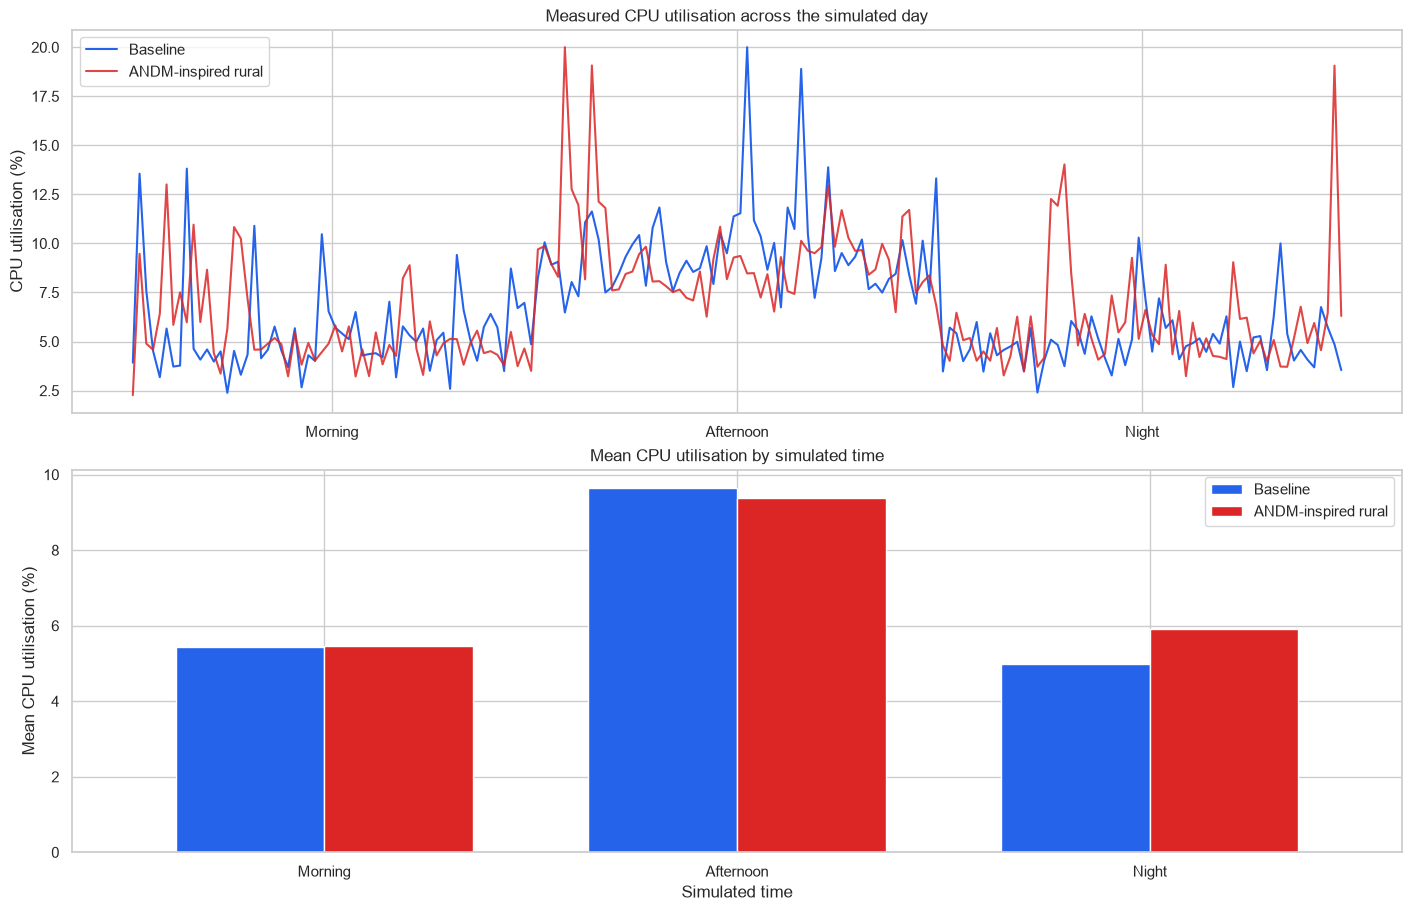

In [10]:
# Draw the measured CPU traces and their phase averages.
fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)

axes[0].plot(
    baseline_measured["sample"],
    baseline_measured["cpu_used"],
    label="Baseline",
    color="#2563eb",
    linewidth=1.5,
)
axes[0].plot(
    rural_measured["sample"],
    rural_measured["cpu_used"],
    label="ANDM-inspired rural",
    color="#dc2626",
    linewidth=1.5,
    alpha=0.85,
)
axes[0].set_title("Measured CPU utilisation across the simulated day")
axes[0].set_ylabel("CPU utilisation (%)")
axes[0].set_xticks(PHASE_TICKS, PHASES)
axes[0].legend()

cpu_means = phase_summary.pivot(
    index="simulated_time", columns="scenario_key", values="cpu_mean_pct"
).reindex(PHASES)
cpu_means.plot.bar(
    ax=axes[1],
    color=["#2563eb", "#dc2626"],
    width=0.72,
)
axes[1].set_title("Mean CPU utilisation by simulated time")
axes[1].set_xlabel("Simulated time")
axes[1].set_ylabel("Mean CPU utilisation (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Baseline", "ANDM-inspired rural"])

plt.savefig(FIGURE_DIR / "01_measured_cpu.png", dpi=180, bbox_inches="tight")
plt.show()

## Throughput Visualisation

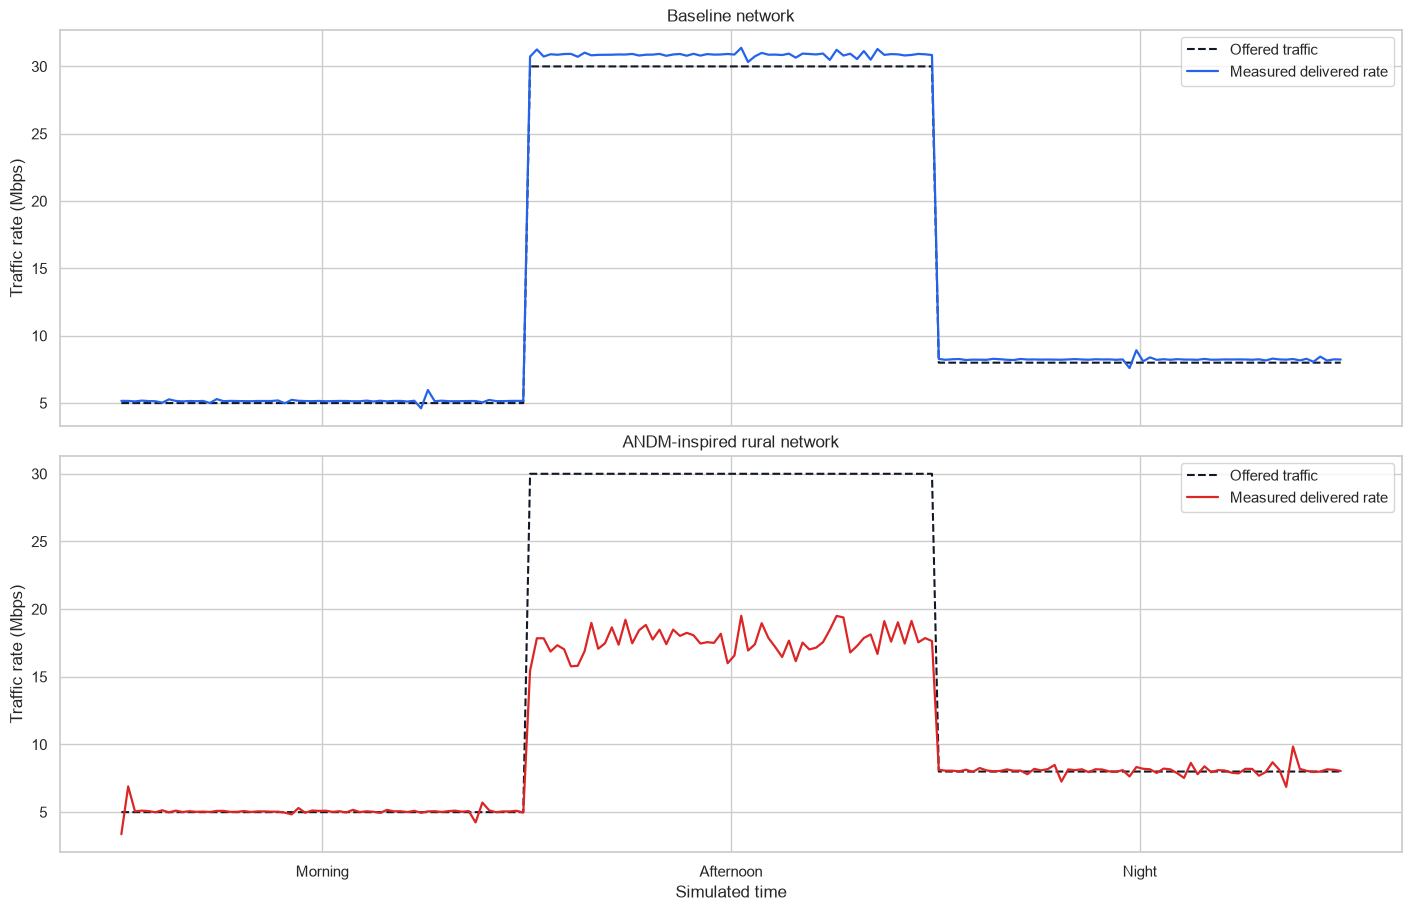

In [11]:
# Compare offered and delivered traffic without counting repeated interface rows.
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, constrained_layout=True)

for axis, frame, title, colour in [
    (axes[0], baseline_measured, "Baseline network", "#2563eb"),
    (axes[1], rural_measured, "ANDM-inspired rural network", "#dc2626"),
]:
    axis.plot(
        frame["sample"],
        frame["offered_load_mbps"],
        label="Offered traffic",
        color="#111827",
        linestyle="--",
        linewidth=1.5,
    )
    axis.plot(
        frame["sample"],
        frame["delivered_rate_mbps"],
        label="Measured delivered rate",
        color=colour,
        linewidth=1.6,
    )
    axis.set_title(title)
    axis.set_ylabel("Traffic rate (Mbps)")
    axis.set_xticks(PHASE_TICKS, PHASES)
    axis.legend()

axes[1].set_xlabel("Simulated time")
plt.savefig(FIGURE_DIR / "02_measured_throughput.png", dpi=180, bbox_inches="tight")
plt.show()

## Latency and Packet-Loss Visualisation

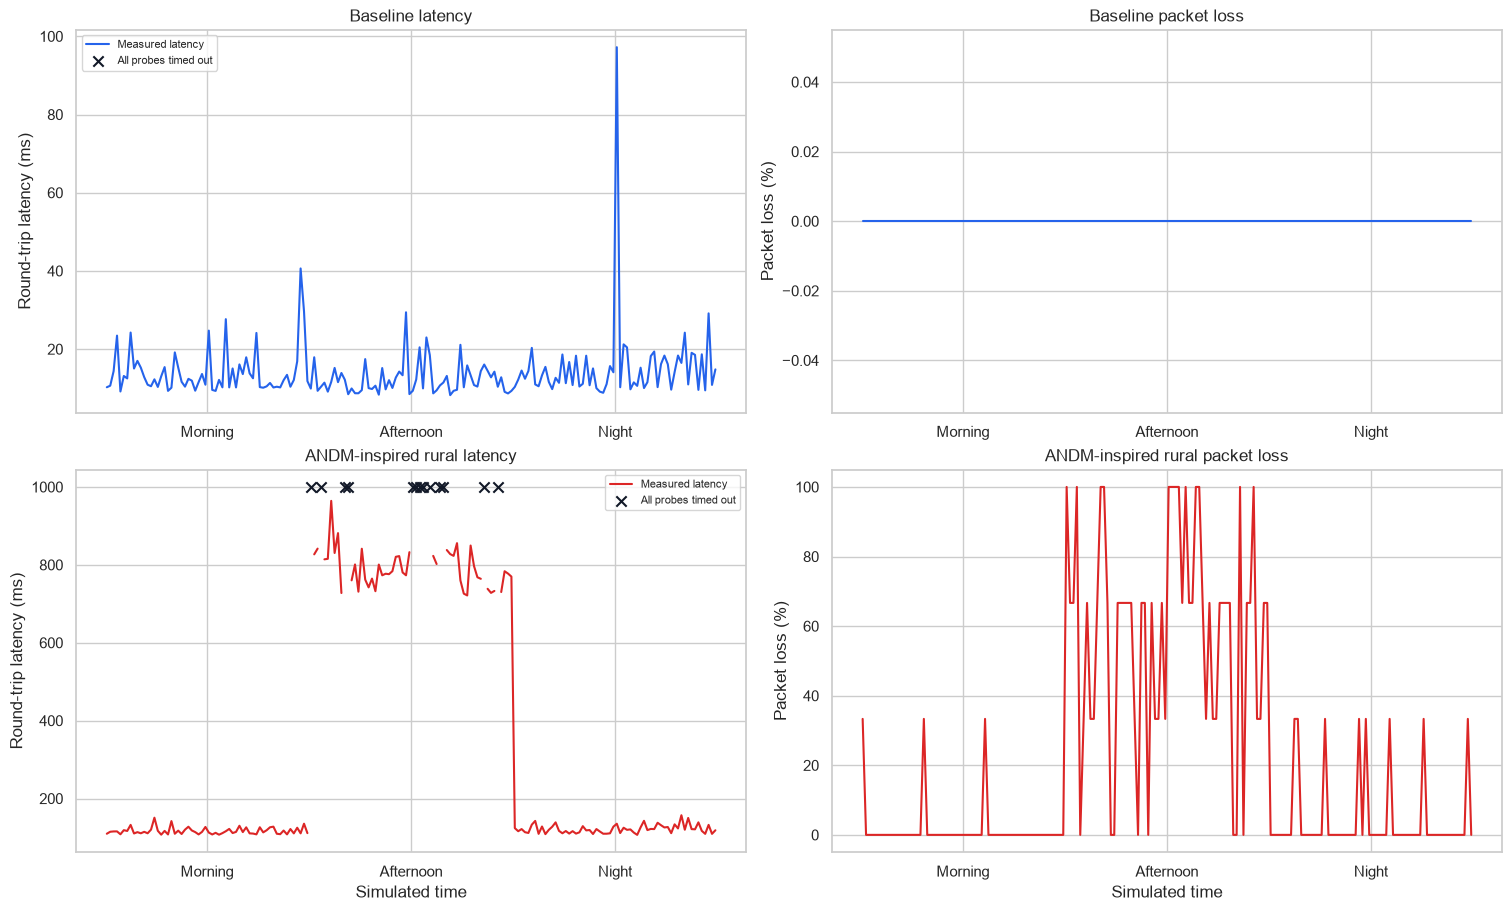

In [12]:
# Show measured latency gaps instead of changing failed probes into zero.
fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

for row, frame, label, colour in [
    (0, baseline_measured, "Baseline", "#2563eb"),
    (1, rural_measured, "ANDM-inspired rural", "#dc2626"),
]:
    axes[row, 0].plot(
        frame["sample"],
        frame["latency_ms"],
        color=colour,
        linewidth=1.5,
        label="Measured latency",
    )
    timeout_rows = frame[frame["latency_timed_out"]]
    axes[row, 0].scatter(
        timeout_rows["sample"],
        np.full(len(timeout_rows), 1000.0),
        marker="x",
        s=55,
        color="#111827",
        label="All probes timed out",
    )
    axes[row, 0].set_title(f"{label} latency")
    axes[row, 0].set_ylabel("Round-trip latency (ms)")
    axes[row, 0].set_xticks(PHASE_TICKS, PHASES)
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].plot(
        frame["sample"],
        frame["packet_loss_pct"],
        color=colour,
        linewidth=1.5,
    )
    axes[row, 1].set_title(f"{label} packet loss")
    axes[row, 1].set_ylabel("Packet loss (%)")
    axes[row, 1].set_xticks(PHASE_TICKS, PHASES)

axes[1, 0].set_xlabel("Simulated time")
axes[1, 1].set_xlabel("Simulated time")
plt.savefig(FIGURE_DIR / "03_measured_latency_loss.png", dpi=180, bbox_inches="tight")
plt.show()

## Phase Comparison Visualisation

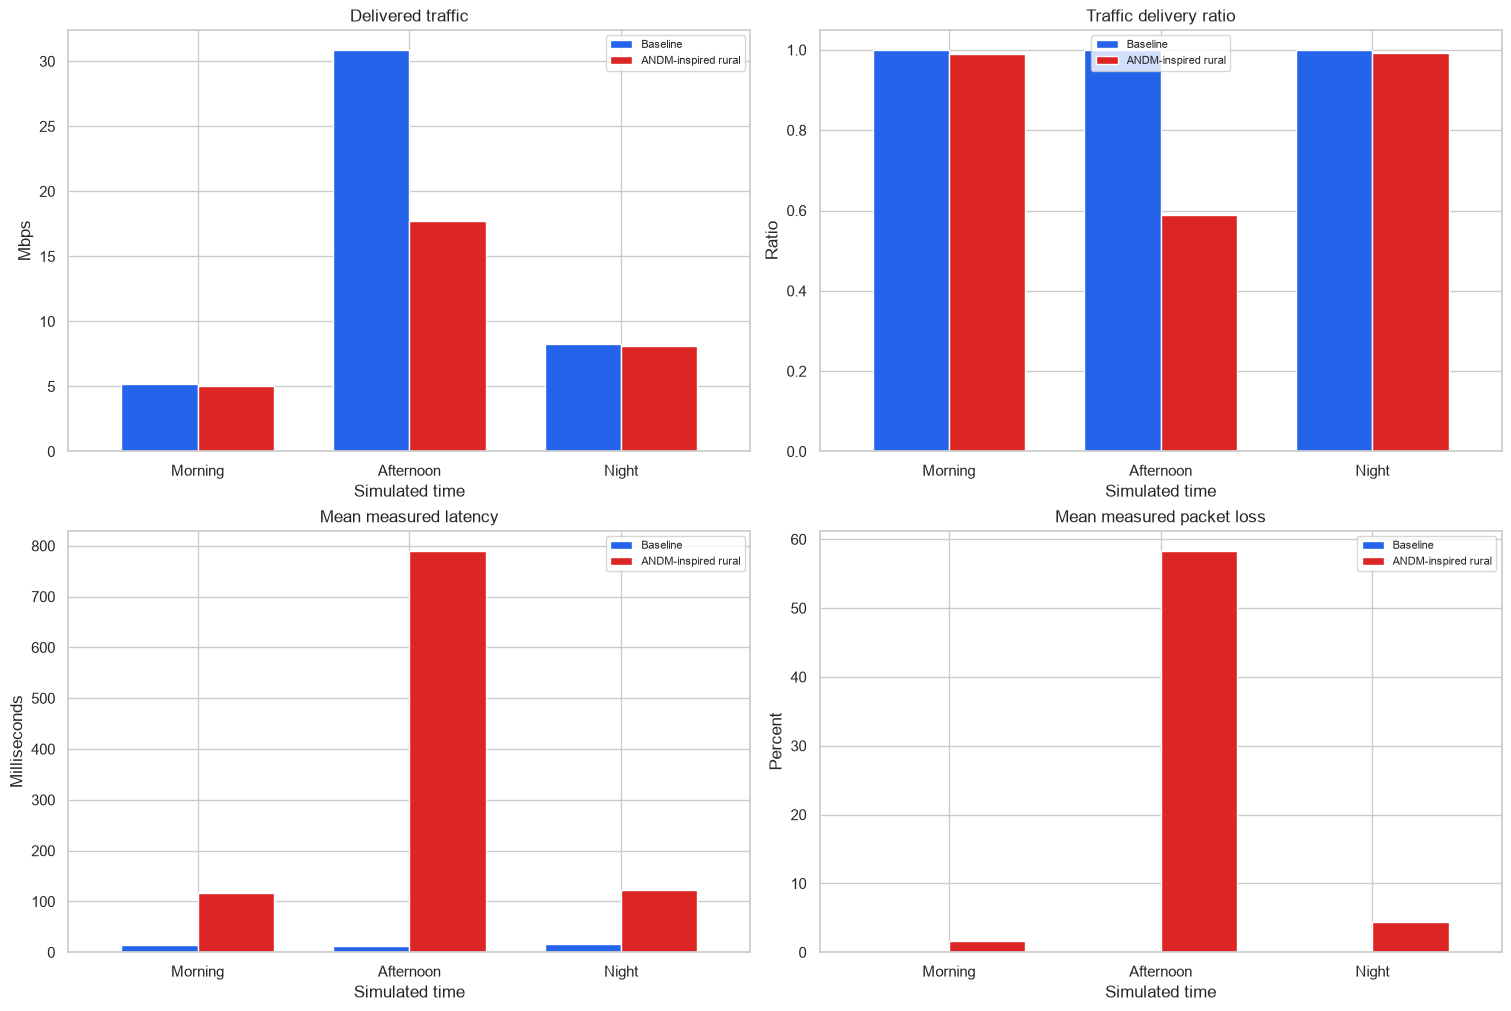

In [13]:
# Compare the phase-level network findings in one figure.
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

for axis, value, title, ylabel in [
    (axes[0, 0], "delivered_mean_mbps", "Delivered traffic", "Mbps"),
    (axes[0, 1], "delivery_ratio_mean", "Traffic delivery ratio", "Ratio"),
    (axes[1, 0], "latency_mean_ms", "Mean measured latency", "Milliseconds"),
    (axes[1, 1], "loss_mean_pct", "Mean measured packet loss", "Percent"),
]:
    table = phase_summary.pivot(
        index="simulated_time", columns="scenario_key", values=value
    ).reindex(PHASES)
    table.plot.bar(
        ax=axis,
        color=["#2563eb", "#dc2626"],
        width=0.72,
    )
    axis.set_title(title)
    axis.set_xlabel("Simulated time")
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=0)
    axis.legend(["Baseline", "ANDM-inspired rural"], fontsize=8)

plt.savefig(FIGURE_DIR / "04_phase_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## Phase-Aware Train, Validation and Test Splits

In [14]:
# Split each phase separately so every split contains all three daily periods.
def phase_aware_split(frame):
    split_parts = {"train": [], "validation": [], "test": []}
    split_ranges = {
        "train": (0, 36),
        "validation": (36, 48),
        "test": (48, 60),
    }
    for phase in PHASES:
        phase_frame = frame[frame["simulated_time"] == phase].sort_values("sample")
        phase_frame = phase_frame.reset_index(drop=True)
        for split_name, (start, stop) in split_ranges.items():
            split_parts[split_name].append(phase_frame.iloc[start:stop].copy())
    return {
        split_name: pd.concat(parts, ignore_index=True)
        for split_name, parts in split_parts.items()
    }


# Apply the same time-ordered split to both scenarios.
baseline_splits = phase_aware_split(baseline_measured)
rural_splits = phase_aware_split(rural_measured)

# Display the number of rows retained from each phase.
split_rows = []
for scenario_name, split_collection in [
    ("baseline", baseline_splits),
    ("rural", rural_splits),
]:
    for split_name, frame in split_collection.items():
        for phase in PHASES:
            split_rows.append(
                {
                    "scenario": scenario_name,
                    "split": split_name,
                    "phase": phase,
                    "rows": int((frame["simulated_time"] == phase).sum()),
                }
            )

split_summary = pd.DataFrame(split_rows)
display(split_summary)

,scenario,split,phase,rows
0,baseline,train,Morning,36
1,baseline,train,Afternoon,36
2,baseline,train,Night,36
3,baseline,validation,Morning,12
4,baseline,validation,Afternoon,12
5,baseline,validation,Night,12
6,baseline,test,Morning,12
7,baseline,test,Afternoon,12
8,baseline,test,Night,12
9,rural,train,Morning,36


## Compute-Load Calibration

In [15]:
# Use only baseline training data to calibrate the simulated service load.
BASELINE_CPU_P95 = float(baseline_splits["train"]["cpu_used"].quantile(0.95))
CPU_CALIBRATION_FACTOR = CPU_TARGET_PERCENT / max(BASELINE_CPU_P95, 1e-6)

# Add the calibrated load without changing the measured CPU column.
def add_compute_load(frame):
    prepared = frame.copy()
    prepared["calibrated_compute_load"] = np.clip(
        prepared["cpu_used"] * CPU_CALIBRATION_FACTOR,
        0.0,
        160.0,
    )
    return prepared


# Apply the baseline-derived factor to every split.
baseline_splits = {
    name: add_compute_load(frame)
    for name, frame in baseline_splits.items()
}
rural_splits = {
    name: add_compute_load(frame)
    for name, frame in rural_splits.items()
}

print(f"Baseline training CPU 95th percentile: {BASELINE_CPU_P95:.4f}%")
print(f"Simulation-only CPU calibration factor: {CPU_CALIBRATION_FACTOR:.4f}")
print("Measured cpu_used values remain unchanged in the evidence tables.")

Baseline training CPU 95th percentile: 11.4820%
Simulation-only CPU calibration factor: 6.0965
Measured cpu_used values remain unchanged in the evidence tables.


## Custom vCPU Environment

In [16]:
# Simulate vCPU decisions while keeping measured network performance unchanged.
class ANDMMeasuredResourceEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, measured_frame):
        super().__init__()
        self.frame = measured_frame.reset_index(drop=True).copy()
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=np.zeros(9, dtype=np.float32),
            high=np.ones(9, dtype=np.float32),
            dtype=np.float32,
        )
        self.order = np.arange(len(self.frame))
        self.position = 0
        self.vcpu = INITIAL_VCPU

    # Return the measured row currently being processed.
    def current_row(self):
        return self.frame.iloc[self.order[self.position]]

    # Convert one measured row and the current vCPU decision into nine state values.
    def _state(self, row):
        phase_state = [float(row["simulated_time"] == phase) for phase in PHASES]
        return np.array(
            [
                np.clip(row["calibrated_compute_load"] / 160.0, 0.0, 1.0),
                np.clip(row["offered_load_mbps"] / 30.0, 0.0, 1.0),
                np.clip(row["delivery_ratio"], 0.0, 1.0),
                np.clip(row["latency_for_model_ms"] / 1000.0, 0.0, 1.0),
                np.clip(row["packet_loss_pct"] / 100.0, 0.0, 1.0),
                self.vcpu / MAX_VCPU,
                *phase_state,
            ],
            dtype=np.float32,
        )

    # Start one episode from a reproducible offset in the measured trace.
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        requested_offset = None if options is None else options.get("start_offset")
        offset = (
            int(self.np_random.integers(0, len(self.frame)))
            if requested_offset is None
            else int(requested_offset) % len(self.frame)
        )
        self.order = np.roll(np.arange(len(self.frame)), -offset)
        self.position = 0
        self.vcpu = INITIAL_VCPU
        return self._state(self.current_row()), {}

    # Apply one keep, add or remove action and calculate its simulated reward.
    def step(self, action):
        action = int(action)
        previous_vcpu = self.vcpu
        if action == 1:
            self.vcpu = min(MAX_VCPU, self.vcpu + 1)
        elif action == 2:
            self.vcpu = max(MIN_VCPU, self.vcpu - 1)

        row = self.current_row()
        projected_cpu = (
            row["calibrated_compute_load"] * REFERENCE_VCPU / self.vcpu
        )
        compute_satisfaction = min(1.0, 100.0 / max(projected_cpu, 1e-6))
        network_satisfaction = float(row["delivery_ratio"])
        service_satisfaction = compute_satisfaction * network_satisfaction
        overload_penalty = max(projected_cpu - 85.0, 0.0) / 85.0
        resource_cost = 0.10 * self.vcpu
        change_cost = 0.05 if self.vcpu != previous_vcpu else 0.0
        reward = (
            2.0 * service_satisfaction
            - 1.5 * overload_penalty
            - resource_cost
            - change_cost
        )

        info = {
            "sample": int(row["sample"]),
            "simulated_time": row["simulated_time"],
            "measured_cpu_pct": float(row["cpu_used"]),
            "projected_cpu_pct": float(projected_cpu),
            "delivery_ratio": network_satisfaction,
            "latency_ms": float(row["latency_for_model_ms"]),
            "packet_loss_pct": float(row["packet_loss_pct"]),
            "service_satisfaction": float(service_satisfaction),
            "vcpu": int(self.vcpu),
            "overload": bool(projected_cpu > 100.0),
        }

        self.position += 1
        terminated = self.position >= len(self.frame)
        next_row = row if terminated else self.current_row()
        return self._state(next_row), float(reward), terminated, False, info

## Environment Check

In [17]:
# Check the environment rules before training any agent.
environment_check = ANDMMeasuredResourceEnv(baseline_splits["train"])
check_env(environment_check, warn=True)

# Run one visible action to confirm the returned values.
first_state, _ = environment_check.reset(seed=42, options={"start_offset": 0})
second_state, reward, terminated, truncated, step_info = environment_check.step(0)

print("First state:", first_state)
print("Second state:", second_state)
print("Reward:", round(reward, 4))
display(pd.Series(step_info, name="value").to_frame())

First state: [0.1494246  0.16666667 1.         0.01024    0.         0.5
 1.         0.         0.        ]
Second state: [0.51645523 0.16666667 1.         0.010638   0.         0.5
 1.         0.         0.        ]
Reward: 1.8


,value
sample,0
simulated_time,Morning
measured_cpu_pct,3.9216
projected_cpu_pct,23.907936
delivery_ratio,1.0
latency_ms,10.24
packet_loss_pct,0.0
service_satisfaction,1.0
vcpu,2
overload,False


## Simple Comparison Policies

In [18]:
# Keep the simulated allocation at two vCPUs.
def fixed_two_policy(environment):
    if environment.vcpu < 2:
        return 1
    if environment.vcpu > 2:
        return 2
    return 0


# Add or remove vCPUs using one visible CPU threshold rule.
def cpu_rule_policy(environment):
    row = environment.current_row()
    projected_cpu = (
        row["calibrated_compute_load"] * REFERENCE_VCPU / environment.vcpu
    )
    if projected_cpu > 85.0 and environment.vcpu < MAX_VCPU:
        return 1
    if projected_cpu < 40.0 and environment.vcpu > MIN_VCPU:
        return 2
    return 0

## Evaluation Functions

In [19]:
# Evaluate one model or simple policy on one measured split.
def evaluate_one_episode(
    policy_name,
    measured_frame,
    seed,
    model=None,
    policy_function=None,
    start_offset=None,
):
    environment = ANDMMeasuredResourceEnv(measured_frame)
    options = None if start_offset is None else {"start_offset": start_offset}
    state, _ = environment.reset(seed=seed, options=options)
    trace_rows = []
    total_reward = 0.0
    done = False

    while not done:
        if model is not None:
            action, _ = model.predict(state, deterministic=True)
            action = int(np.asarray(action).item())
        else:
            action = int(policy_function(environment))

        state, reward, terminated, truncated, info = environment.step(action)
        total_reward += reward
        trace_rows.append(
            {
                "policy": policy_name,
                "seed": seed,
                "reward": reward,
                **info,
            }
        )
        done = terminated or truncated

    trace = pd.DataFrame(trace_rows)
    episode = {
        "policy": policy_name,
        "seed": seed,
        "episode_reward": total_reward,
        "mean_satisfaction": trace["service_satisfaction"].mean(),
        "mean_vcpu": trace["vcpu"].mean(),
        "overload_rate": trace["overload"].mean(),
    }
    return episode, trace


# Repeat an evaluation with paired offsets for fair comparisons.
def evaluate_policy(
    policy_name,
    measured_frame,
    seeds,
    model=None,
    policy_function=None,
):
    episode_rows = []
    trace_frames = []
    for seed in seeds:
        episode, trace = evaluate_one_episode(
            policy_name,
            measured_frame,
            seed,
            model=model,
            policy_function=policy_function,
        )
        episode_rows.append(episode)
        trace_frames.append(trace)
    return pd.DataFrame(episode_rows), pd.concat(trace_frames, ignore_index=True)


# Reduce repeated episodes to comparable policy-level results.
def summarise_episodes(episode_frame):
    return {
        "mean_reward": episode_frame["episode_reward"].mean(),
        "std_reward": episode_frame["episode_reward"].std(),
        "mean_satisfaction": episode_frame["mean_satisfaction"].mean(),
        "mean_vcpu": episode_frame["mean_vcpu"].mean(),
        "mean_overload_rate": episode_frame["overload_rate"].mean(),
    }

## Simple Baseline Results

In [20]:
# Evaluate the non-learning policies before training DQN and PPO.
fixed_validation_rows, _ = evaluate_policy(
    "Fixed-vCPU-2",
    baseline_splits["validation"],
    EVALUATION_SEEDS,
    policy_function=fixed_two_policy,
)
rule_validation_rows, _ = evaluate_policy(
    "CPU-rule",
    baseline_splits["validation"],
    EVALUATION_SEEDS,
    policy_function=cpu_rule_policy,
)

# Display the simple-policy targets the learned agents should beat.
simple_validation_summary = pd.DataFrame(
    [
        {"policy": "Fixed-vCPU-2", **summarise_episodes(fixed_validation_rows)},
        {"policy": "CPU-rule", **summarise_episodes(rule_validation_rows)},
    ]
)
display(simple_validation_summary.round(4))

,policy,mean_reward,std_reward,mean_satisfaction,mean_vcpu,mean_overload_rate
0,Fixed-vCPU-2,63.8487,0.0000,0.9942,2.0000,0.0278
1,CPU-rule,66.5020,0.0176,0.9979,1.3907,0.0000


## DQN and PPO Training Functions

In [21]:
# Create one DQN or PPO agent with a small two-layer neural network.
def make_agent(algorithm, environment, seed):
    policy_settings = {"net_arch": [64, 64]}
    if algorithm == "DQN":
        return DQN(
            "MlpPolicy",
            environment,
            learning_rate=5e-4,
            buffer_size=10_000,
            learning_starts=500,
            batch_size=64,
            gamma=0.97,
            target_update_interval=250,
            exploration_fraction=0.30,
            policy_kwargs=policy_settings,
            seed=seed,
            verbose=0,
            device="cpu",
        )
    if algorithm == "PPO":
        return PPO(
            "MlpPolicy",
            environment,
            learning_rate=3e-4,
            n_steps=128,
            batch_size=64,
            gamma=0.97,
            gae_lambda=0.95,
            n_epochs=10,
            policy_kwargs=policy_settings,
            seed=seed,
            verbose=0,
            device="cpu",
        )
    raise ValueError(f"Unknown algorithm: {algorithm}")


# Train or resume every seed and evaluate it on the same baseline validation split.
def train_algorithm_across_seeds(algorithm):
    result_rows = []
    model_paths = {}

    for seed in TRAINING_SEEDS:
        environment = ANDMMeasuredResourceEnv(baseline_splits["train"])
        model_path = MODEL_DIR / f"{algorithm.lower()}_seed_{seed}.zip"
        started = time.perf_counter()

        if RESUME_MODELS and model_path.exists():
            model_class = DQN if algorithm == "DQN" else PPO
            model = model_class.load(model_path, env=environment, device="cpu")
            resumed = True
        else:
            model = make_agent(algorithm, environment, seed)
            model.learn(total_timesteps=TRAIN_TIMESTEPS)
            model.save(model_path)
            resumed = False

        validation_rows, _ = evaluate_policy(
            f"{algorithm}-seed-{seed}",
            baseline_splits["validation"],
            EVALUATION_SEEDS,
            model=model,
        )
        metrics = summarise_episodes(validation_rows)
        result_rows.append(
            {
                "algorithm": algorithm,
                "seed": seed,
                "training_seconds": time.perf_counter() - started,
                "resumed_model": resumed,
                **{f"validation_{key}": value for key, value in metrics.items()},
            }
        )
        model_paths[seed] = model_path
        print(
            f"{algorithm} seed {seed}: "
            f"reward={metrics['mean_reward']:.4f}, "
            f"mean_vcpu={metrics['mean_vcpu']:.4f}, "
            f"resumed={resumed}"
        )

    return pd.DataFrame(result_rows), model_paths

## Train DQN

In [22]:
# Train DQN with the declared seeds and budget.
dqn_results, dqn_model_paths = train_algorithm_across_seeds("DQN")
display(dqn_results.round(4))
dqn_results.to_csv(OUTPUT_DIR / "dqn_seed_results.csv", index=False)

DQN seed 7: reward=65.9267, mean_vcpu=1.5759, resumed=True
DQN seed 17: reward=60.7320, mean_vcpu=2.9852, resumed=True
DQN seed 29: reward=65.7131, mean_vcpu=1.4685, resumed=True
DQN seed 42: reward=65.9733, mean_vcpu=1.5648, resumed=True
DQN seed 61: reward=55.9370, mean_vcpu=1.0389, resumed=True
DQN seed 73: reward=64.2967, mean_vcpu=1.9981, resumed=True
DQN seed 89: reward=64.2967, mean_vcpu=1.9981, resumed=True
DQN seed 101: reward=64.2967, mean_vcpu=1.9981, resumed=True
DQN seed 127: reward=65.7867, mean_vcpu=1.6241, resumed=True
DQN seed 149: reward=65.5900, mean_vcpu=1.6407, resumed=True


,algorithm,seed,training_seconds,resumed_model,validation_mean_reward,validation_std_reward,validation_mean_satisfaction,validation_mean_vcpu,validation_mean_overload_rate
0,DQN,7,7.4582,True,65.9267,0.1294,0.9979,1.5759,0.0000
1,DQN,17,1.3451,True,60.7320,0.0516,0.9979,2.9852,0.0000
2,DQN,29,1.2992,True,65.7131,0.1548,0.9976,1.4685,0.0019
3,DQN,42,1.3194,True,65.9733,0.2347,0.9979,1.5648,0.0000
4,DQN,61,1.3138,True,55.9370,3.1343,0.9422,1.0389,0.2444
5,DQN,73,1.3172,True,64.2967,0.0611,0.9979,1.9981,0.0000
6,DQN,89,1.3171,True,64.2967,0.0611,0.9979,1.9981,0.0000
7,DQN,101,1.4224,True,64.2967,0.0611,0.9979,1.9981,0.0000
8,DQN,127,1.3574,True,65.7867,0.3276,0.9979,1.6241,0.0000
9,DQN,149,1.3248,True,65.5900,0.0176,0.9979,1.6407,0.0000


## Train PPO

In [23]:
# Train PPO under the same seeds, data and budget used for DQN.
ppo_results, ppo_model_paths = train_algorithm_across_seeds("PPO")
display(ppo_results.round(4))
ppo_results.to_csv(OUTPUT_DIR / "ppo_seed_results.csv", index=False)

PPO seed 7: reward=60.7320, mean_vcpu=2.9852, resumed=True
PPO seed 17: reward=63.8487, mean_vcpu=2.0000, resumed=True
PPO seed 29: reward=63.5767, mean_vcpu=2.2407, resumed=True
PPO seed 42: reward=61.4967, mean_vcpu=2.7963, resumed=True
PPO seed 61: reward=61.4967, mean_vcpu=2.7963, resumed=True
PPO seed 73: reward=60.7300, mean_vcpu=2.9815, resumed=True
PPO seed 89: reward=57.4453, mean_vcpu=3.9722, resumed=True
PPO seed 101: reward=55.4103, mean_vcpu=1.1852, resumed=True
PPO seed 127: reward=63.8487, mean_vcpu=2.0000, resumed=True
PPO seed 149: reward=62.8800, mean_vcpu=2.4000, resumed=True


,algorithm,seed,training_seconds,resumed_model,validation_mean_reward,validation_std_reward,validation_mean_satisfaction,validation_mean_vcpu,validation_mean_overload_rate
0,PPO,7,1.9080,True,60.7320,0.0516,0.9979,2.9852,0.0000
1,PPO,17,1.7815,True,63.8487,0.0000,0.9942,2.0000,0.0278
2,PPO,29,2.0272,True,63.5767,0.4511,0.9979,2.2407,0.0000
3,PPO,42,2.0190,True,61.4967,0.9248,0.9979,2.7963,0.0000
4,PPO,61,1.7896,True,61.4967,0.9248,0.9979,2.7963,0.0000
5,PPO,73,2.2315,True,60.7300,0.0935,0.9979,2.9815,0.0000
6,PPO,89,2.1574,True,57.4453,0.0000,0.9979,3.9722,0.0000
7,PPO,101,1.9158,True,55.4103,2.8808,0.9422,1.1852,0.2444
8,PPO,127,1.9139,True,63.8487,0.0000,0.9942,2.0000,0.0278
9,PPO,149,1.9091,True,62.8800,0.1788,0.9979,2.4000,0.0000


## Fair Agent Selection

,seeds,mean_validation_reward,std_validation_reward,mean_validation_satisfaction,mean_validation_vcpu,mean_validation_overload
algorithm,,,,,,
DQN,10,63.8549,3.1973,0.9923,1.7893,0.0246
PPO,10,61.1465,2.8029,0.9916,2.5357,0.0300


Paired DQN-PPO reward difference: 2.7084
Paired 95% bootstrap interval: (0.0330, 5.1045)
Selected algorithm: DQN
Selection basis: DQN paired interval is above zero
Selected seed: 42


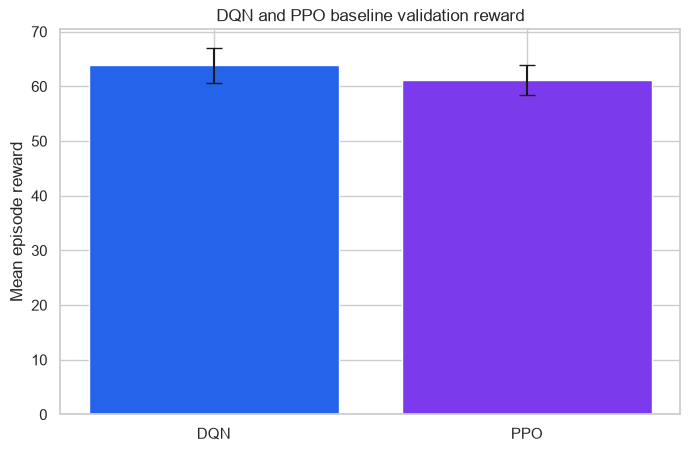

In [24]:
# Calculate a paired bootstrap interval from matching seed results.
def paired_bootstrap_interval(first, second, sample_count, seed=2026):
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    differences = first - second
    generator = np.random.default_rng(seed)
    bootstrap_means = np.array(
        [
            generator.choice(differences, size=len(differences), replace=True).mean()
            for _ in range(sample_count)
        ]
    )
    return (
        float(differences.mean()),
        float(np.percentile(bootstrap_means, 2.5)),
        float(np.percentile(bootstrap_means, 97.5)),
    )


# Combine the seed-level results without hiding their variation.
algorithm_runs = pd.concat([dqn_results, ppo_results], ignore_index=True)
algorithm_summary = (
    algorithm_runs.groupby("algorithm")
    .agg(
        seeds=("seed", "count"),
        mean_validation_reward=("validation_mean_reward", "mean"),
        std_validation_reward=("validation_mean_reward", "std"),
        mean_validation_satisfaction=("validation_mean_satisfaction", "mean"),
        mean_validation_vcpu=("validation_mean_vcpu", "mean"),
        mean_validation_overload=("validation_mean_overload_rate", "mean"),
    )
)

# Compare DQN minus PPO using the same training seeds.
dqn_ordered = dqn_results.sort_values("seed")
ppo_ordered = ppo_results.sort_values("seed")
selection_difference, selection_low, selection_high = paired_bootstrap_interval(
    dqn_ordered["validation_mean_reward"],
    ppo_ordered["validation_mean_reward"],
    BOOTSTRAP_SAMPLES,
)

# Use statistical evidence first and mean reward only as a declared tie-breaker.
if selection_low > 0:
    SELECTED_ALGORITHM = "DQN"
    SELECTION_BASIS = "DQN paired interval is above zero"
elif selection_high < 0:
    SELECTED_ALGORITHM = "PPO"
    SELECTION_BASIS = "PPO paired interval is above zero"
else:
    SELECTED_ALGORITHM = algorithm_summary["mean_validation_reward"].idxmax()
    SELECTION_BASIS = "interval includes zero; higher mean reward used as tie-breaker"

# Select the best validation seed only after choosing the algorithm.
selected_runs = algorithm_runs[algorithm_runs["algorithm"] == SELECTED_ALGORITHM]
BEST_SEED = int(
    selected_runs.sort_values("validation_mean_reward", ascending=False).iloc[0]["seed"]
)
CHAMPION_PATH = (
    dqn_model_paths[BEST_SEED]
    if SELECTED_ALGORITHM == "DQN"
    else ppo_model_paths[BEST_SEED]
)

display(algorithm_summary.round(4))
print(f"Paired DQN-PPO reward difference: {selection_difference:.4f}")
print(f"Paired 95% bootstrap interval: ({selection_low:.4f}, {selection_high:.4f})")
print(f"Selected algorithm: {SELECTED_ALGORITHM}")
print(f"Selection basis: {SELECTION_BASIS}")
print(f"Selected seed: {BEST_SEED}")

# Plot validation means and their seed variation.
plot_summary = algorithm_summary.reset_index()
plt.figure(figsize=(8, 5))
plt.bar(
    plot_summary["algorithm"],
    plot_summary["mean_validation_reward"],
    yerr=plot_summary["std_validation_reward"],
    color=["#2563eb", "#7c3aed"],
    capsize=6,
)
plt.title("DQN and PPO baseline validation reward")
plt.ylabel("Mean episode reward")
plt.savefig(FIGURE_DIR / "05_agent_selection.png", dpi=180, bbox_inches="tight")
plt.show()

## Untouched Baseline Test

In [25]:
# Load the selected baseline champion without changing its saved model.
selected_model_class = DQN if SELECTED_ALGORITHM == "DQN" else PPO
champion_environment = ANDMMeasuredResourceEnv(baseline_splits["test"])
champion_model = selected_model_class.load(
    CHAMPION_PATH,
    env=champion_environment,
    device="cpu",
)

# Compare the champion with both simple policies on untouched baseline rows.
champion_baseline_test, _ = evaluate_policy(
    "Champion-v1",
    baseline_splits["test"],
    EVALUATION_SEEDS,
    model=champion_model,
)
fixed_baseline_test, _ = evaluate_policy(
    "Fixed-vCPU-2",
    baseline_splits["test"],
    EVALUATION_SEEDS,
    policy_function=fixed_two_policy,
)
rule_baseline_test, _ = evaluate_policy(
    "CPU-rule",
    baseline_splits["test"],
    EVALUATION_SEEDS,
    policy_function=cpu_rule_policy,
)

baseline_test_summary = pd.DataFrame(
    [
        {"policy": "Champion-v1", **summarise_episodes(champion_baseline_test)},
        {"policy": "Fixed-vCPU-2", **summarise_episodes(fixed_baseline_test)},
        {"policy": "CPU-rule", **summarise_episodes(rule_baseline_test)},
    ]
)
display(baseline_test_summary.round(4))

,policy,mean_reward,std_reward,mean_satisfaction,mean_vcpu,mean_overload_rate
0,Champion-v1,65.357,0.0297,0.9934,1.3611,0.0556
1,Fixed-vCPU-2,64.800,0.0000,1.0000,2.0000,0.0000
2,CPU-rule,66.160,0.0541,1.0000,1.5037,0.0000


## Measured Stress Signal

In [26]:
# Combine measured latency, loss and delivery shortfall into one drift signal.
def add_stress_signal(frame):
    prepared = frame.copy()
    latency_signal = np.clip(prepared["latency_for_model_ms"] / 1000.0, 0.0, 1.0)
    loss_signal = np.clip(prepared["packet_loss_pct"] / 100.0, 0.0, 1.0)
    shortfall_signal = np.clip(prepared["service_shortfall"], 0.0, 1.0)
    prepared["stress_signal"] = (
        0.35 * latency_signal
        + 0.35 * loss_signal
        + 0.30 * shortfall_signal
    )
    return prepared


# Use baseline-only rows for detector calibration.
baseline_calibration_stream = add_stress_signal(
    pd.concat(
        [baseline_splits["train"], baseline_splits["validation"]],
        ignore_index=True,
    )
)

display(
    baseline_calibration_stream[
        ["sample", "simulated_time", "latency_for_model_ms", "packet_loss_pct", "service_shortfall", "stress_signal"]
    ].head()
)

,sample,simulated_time,latency_for_model_ms,packet_loss_pct,service_shortfall,stress_signal
0,0,Morning,10.240,0.0,0.0,0.003584
1,1,Morning,10.638,0.0,0.0,0.003723
2,2,Morning,14.353,0.0,0.0,0.005024
3,3,Morning,23.448,0.0,0.0,0.008207
4,4,Morning,9.162,0.0,0.0,0.003207


## ADWIN Calibration

In [27]:
# Return every point where ADWIN reports a statistical change.
def adwin_event_indices(values, delta_value):
    detector = drift.ADWIN(
        delta=delta_value,
        clock=1,
        min_window_length=5,
        grace_period=10,
    )
    events = []
    for index, value in enumerate(values):
        detector.update(float(value))
        if detector.drift_detected:
            events.append(index)
    return events


# Select the most sensitive delta that creates no baseline false alarm.
ADWIN_CANDIDATES = [0.20, 0.10, 0.05, 0.02, 0.01, 0.005, 0.001]
calibration_rows = []
for delta_value in ADWIN_CANDIDATES:
    events = adwin_event_indices(
        baseline_calibration_stream["stress_signal"],
        delta_value,
    )
    calibration_rows.append(
        {
            "delta": delta_value,
            "baseline_false_alarms": len(events),
            "event_indices": events,
        }
    )

adwin_calibration = pd.DataFrame(calibration_rows)
zero_false_alarm_rows = adwin_calibration[
    adwin_calibration["baseline_false_alarms"] == 0
]
ADWIN_DELTA = (
    float(zero_false_alarm_rows.iloc[0]["delta"])
    if not zero_false_alarm_rows.empty
    else 0.001
)

display(adwin_calibration)
print(f"Selected ADWIN delta: {ADWIN_DELTA}")

,delta,baseline_false_alarms,event_indices
0,0.200,0,[]
1,0.100,0,[]
2,0.050,0,[]
3,0.020,0,[]
4,0.010,0,[]
5,0.005,0,[]
6,0.001,0,[]


Selected ADWIN delta: 0.2


## Baseline-to-Rural Drift Monitoring

,drift_detected,selected_delta,profile_transition_index,first_drift_index,detection_delay_samples,all_drift_indices
0,True,0.2,36,83,47,"[83, 127]"


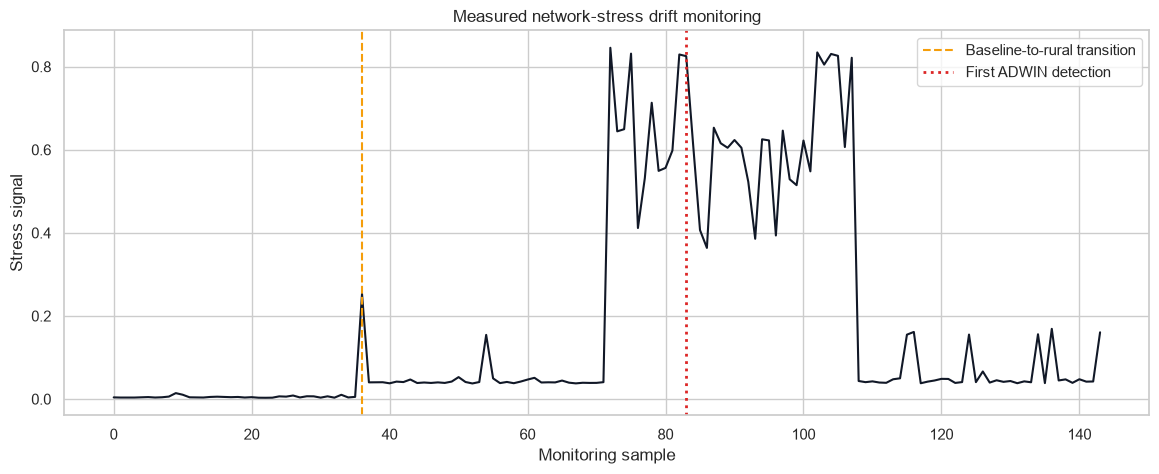

In [28]:
# Join untouched baseline monitoring rows with rural adaptation rows.
baseline_monitoring = baseline_splits["test"].copy()
rural_monitoring = rural_splits["train"].copy()
baseline_monitoring["monitoring_stage"] = "baseline"
rural_monitoring["monitoring_stage"] = "unknown_after_change"
monitoring_trace = pd.concat(
    [baseline_monitoring, rural_monitoring],
    ignore_index=True,
)
monitoring_trace = add_stress_signal(monitoring_trace)

# Detect the change without reading the rural scenario label.
drift_indices = adwin_event_indices(
    monitoring_trace["stress_signal"],
    ADWIN_DELTA,
)
DRIFT_DETECTED = len(drift_indices) > 0
FIRST_DRIFT_INDEX = drift_indices[0] if DRIFT_DETECTED else None
PROFILE_TRANSITION_INDEX = len(baseline_monitoring)
DETECTION_DELAY = (
    FIRST_DRIFT_INDEX - PROFILE_TRANSITION_INDEX
    if DRIFT_DETECTED
    else None
)

drift_log = pd.DataFrame(
    [
        {
            "drift_detected": DRIFT_DETECTED,
            "selected_delta": ADWIN_DELTA,
            "profile_transition_index": PROFILE_TRANSITION_INDEX,
            "first_drift_index": FIRST_DRIFT_INDEX,
            "detection_delay_samples": DETECTION_DELAY,
            "all_drift_indices": drift_indices,
        }
    ]
)
display(drift_log)

# Plot the detector input and the first detected change.
plt.figure(figsize=(14, 5))
plt.plot(monitoring_trace["stress_signal"], color="#111827", linewidth=1.5)
plt.axvline(
    PROFILE_TRANSITION_INDEX,
    color="#f59e0b",
    linestyle="--",
    label="Baseline-to-rural transition",
)
if FIRST_DRIFT_INDEX is not None:
    plt.axvline(
        FIRST_DRIFT_INDEX,
        color="#dc2626",
        linestyle=":",
        linewidth=2,
        label="First ADWIN detection",
    )
plt.title("Measured network-stress drift monitoring")
plt.xlabel("Monitoring sample")
plt.ylabel("Stress signal")
plt.legend()
plt.savefig(FIGURE_DIR / "06_adwin_drift.png", dpi=180, bbox_inches="tight")
plt.show()

## Candidate Adaptation

In [29]:
# Train a candidate only after the measured drift detector reports change.
CANDIDATE_PATH = MODEL_DIR / f"candidate_{SELECTED_ALGORITHM.lower()}_v2.zip"
candidate_model = None

if DRIFT_DETECTED:
    candidate_environment = ANDMMeasuredResourceEnv(rural_splits["train"])
    if RESUME_MODELS and CANDIDATE_PATH.exists():
        candidate_model = selected_model_class.load(
            CANDIDATE_PATH,
            env=candidate_environment,
            device="cpu",
        )
        print("Loaded the saved candidate model.")
    else:
        candidate_model = selected_model_class.load(
            CHAMPION_PATH,
            env=candidate_environment,
            device="cpu",
        )
        candidate_model.learn(
            total_timesteps=ADAPT_TIMESTEPS,
            reset_num_timesteps=False,
        )
        candidate_model.save(CANDIDATE_PATH)
        print("Trained and saved candidate v2 after drift.")
else:
    print("No candidate was trained because ADWIN did not detect drift.")

# Evaluate the old champion before making any promotion decision.
champion_rural_validation, _ = evaluate_policy(
    "Champion-v1-rural-validation",
    rural_splits["validation"],
    EVALUATION_SEEDS,
    model=champion_model,
)

# Evaluate the candidate on the same paired rural validation offsets.
if candidate_model is not None:
    candidate_rural_validation, _ = evaluate_policy(
        "Candidate-v2-rural-validation",
        rural_splits["validation"],
        EVALUATION_SEEDS,
        model=candidate_model,
    )
else:
    candidate_rural_validation = pd.DataFrame()

Loaded the saved candidate model.


## Safe Promotion Decision

,candidate_available,paired_reward_difference,bootstrap_low,bootstrap_high,promote_candidate,deployed_version
0,True,6.4131,4.9489,7.5198,True,v2


,policy,mean_reward,std_reward,mean_satisfaction,mean_vcpu,mean_overload_rate
0,Champion-v1,48.0876,2.5891,0.8247,1.0389,0.3259
1,Candidate-v2,54.5007,0.1276,0.8524,1.4870,0.0815


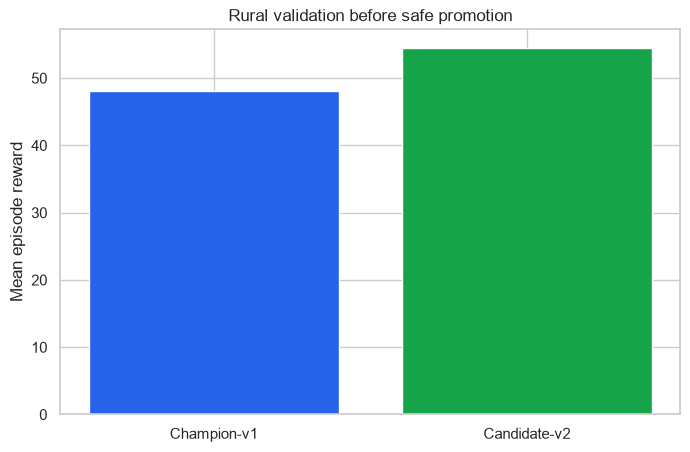

In [30]:
# Promote only when paired validation evidence supports the candidate.
PROMOTE_CANDIDATE = False
promotion_difference = 0.0
promotion_low = 0.0
promotion_high = 0.0

if not candidate_rural_validation.empty:
    champion_ordered = champion_rural_validation.sort_values("seed")
    candidate_ordered = candidate_rural_validation.sort_values("seed")
    promotion_difference, promotion_low, promotion_high = paired_bootstrap_interval(
        candidate_ordered["episode_reward"],
        champion_ordered["episode_reward"],
        BOOTSTRAP_SAMPLES,
        seed=2027,
    )
    candidate_satisfaction = candidate_ordered["mean_satisfaction"].mean()
    champion_satisfaction = champion_ordered["mean_satisfaction"].mean()
    candidate_overload = candidate_ordered["overload_rate"].mean()
    champion_overload = champion_ordered["overload_rate"].mean()
    PROMOTE_CANDIDATE = bool(
        promotion_low > 0
        and candidate_satisfaction >= champion_satisfaction - 0.005
        and candidate_overload <= champion_overload + 0.005
    )

# Keep the current champion when the candidate does not pass all checks.
DEPLOYED_VERSION = "v2" if PROMOTE_CANDIDATE else "v1"
deployed_model = candidate_model if PROMOTE_CANDIDATE else champion_model

promotion_summary = pd.DataFrame(
    [
        {
            "candidate_available": candidate_model is not None,
            "paired_reward_difference": promotion_difference,
            "bootstrap_low": promotion_low,
            "bootstrap_high": promotion_high,
            "promote_candidate": PROMOTE_CANDIDATE,
            "deployed_version": DEPLOYED_VERSION,
        }
    ]
)
display(promotion_summary.round(4))

# Compare champion and candidate rural validation results.
promotion_plot_rows = [
    {"policy": "Champion-v1", **summarise_episodes(champion_rural_validation)}
]
if not candidate_rural_validation.empty:
    promotion_plot_rows.append(
        {"policy": "Candidate-v2", **summarise_episodes(candidate_rural_validation)}
    )
promotion_plot = pd.DataFrame(promotion_plot_rows)
display(promotion_plot.round(4))

plt.figure(figsize=(8, 5))
plt.bar(
    promotion_plot["policy"],
    promotion_plot["mean_reward"],
    color=["#2563eb", "#16a34a"][: len(promotion_plot)],
)
plt.title("Rural validation before safe promotion")
plt.ylabel("Mean episode reward")
plt.savefig(FIGURE_DIR / "07_candidate_promotion.png", dpi=180, bbox_inches="tight")
plt.show()

## Untouched Rural Test

In [31]:
# Test the deployed model only after selection and promotion decisions are complete.
deployed_rural_test, deployed_rural_test_traces = evaluate_policy(
    f"Deployed-{DEPLOYED_VERSION}",
    rural_splits["test"],
    EVALUATION_SEEDS,
    model=deployed_model,
)
fixed_rural_test, fixed_rural_test_traces = evaluate_policy(
    "Fixed-vCPU-2",
    rural_splits["test"],
    EVALUATION_SEEDS,
    policy_function=fixed_two_policy,
)
rule_rural_test, rule_rural_test_traces = evaluate_policy(
    "CPU-rule",
    rural_splits["test"],
    EVALUATION_SEEDS,
    policy_function=cpu_rule_policy,
)

# Keep every final episode and summarise each policy.
final_test_episodes = pd.concat(
    [deployed_rural_test, fixed_rural_test, rule_rural_test],
    ignore_index=True,
)
final_test_summary = pd.DataFrame(
    [
        {"policy": f"Deployed-{DEPLOYED_VERSION}", **summarise_episodes(deployed_rural_test)},
        {"policy": "Fixed-vCPU-2", **summarise_episodes(fixed_rural_test)},
        {"policy": "CPU-rule", **summarise_episodes(rule_rural_test)},
    ]
)
display(final_test_summary.round(4))

,policy,mean_reward,std_reward,mean_satisfaction,mean_vcpu,mean_overload_rate
0,Deployed-v2,54.4176,0.2465,0.8536,1.7130,0.0278
1,Fixed-vCPU-2,53.7076,0.0000,0.8536,2.0000,0.0278
2,CPU-rule,55.8129,0.1660,0.8538,1.3389,0.0259


## Final Policy Visualisation

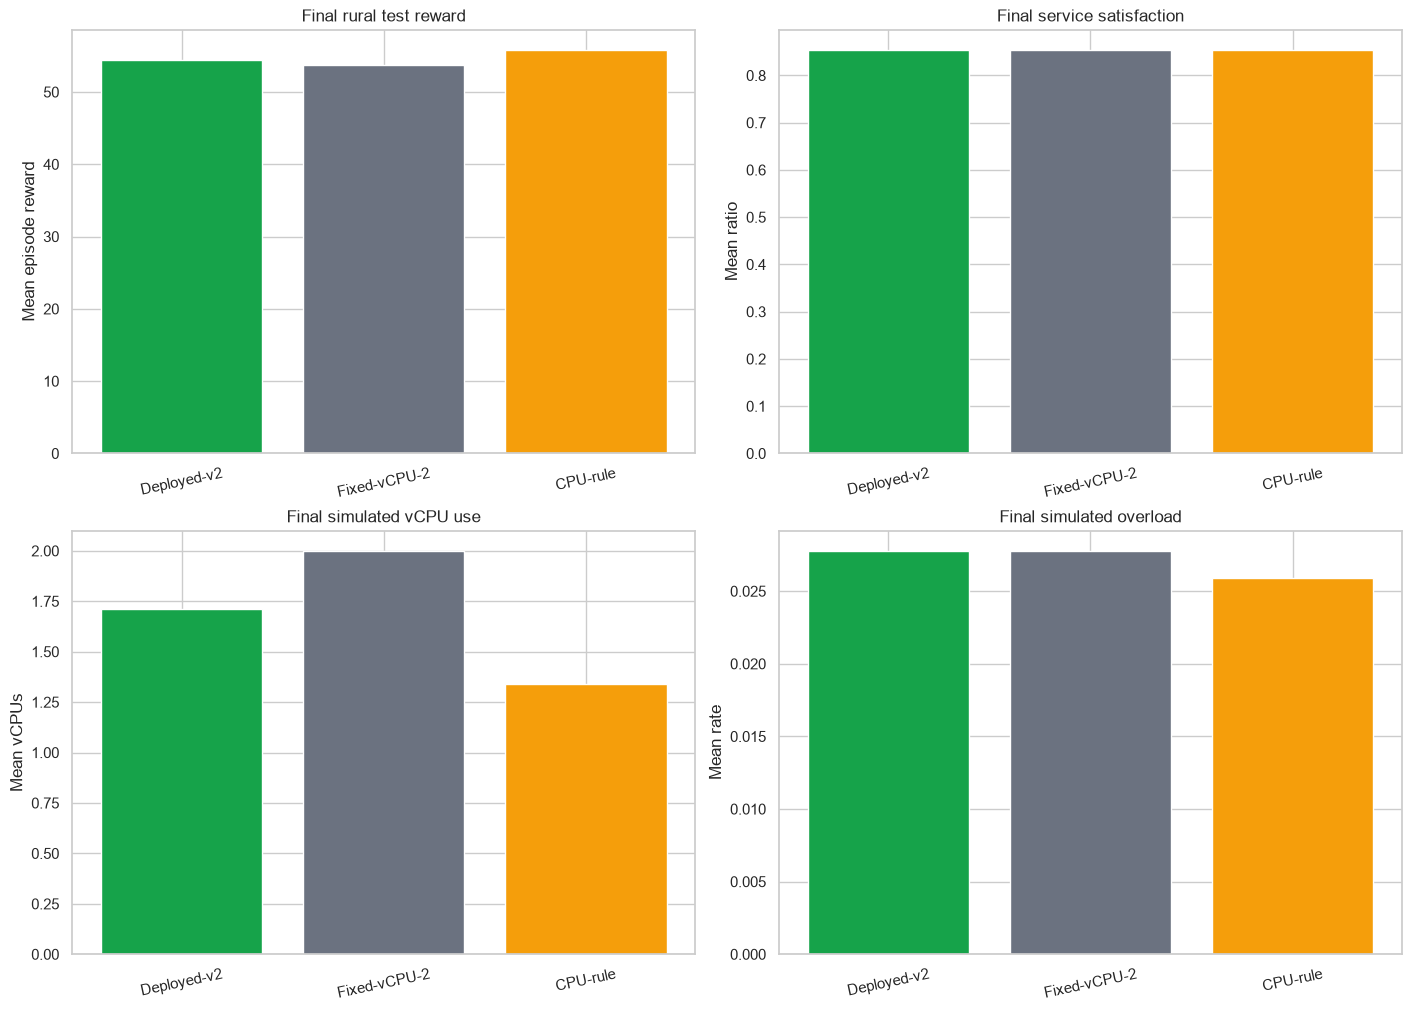

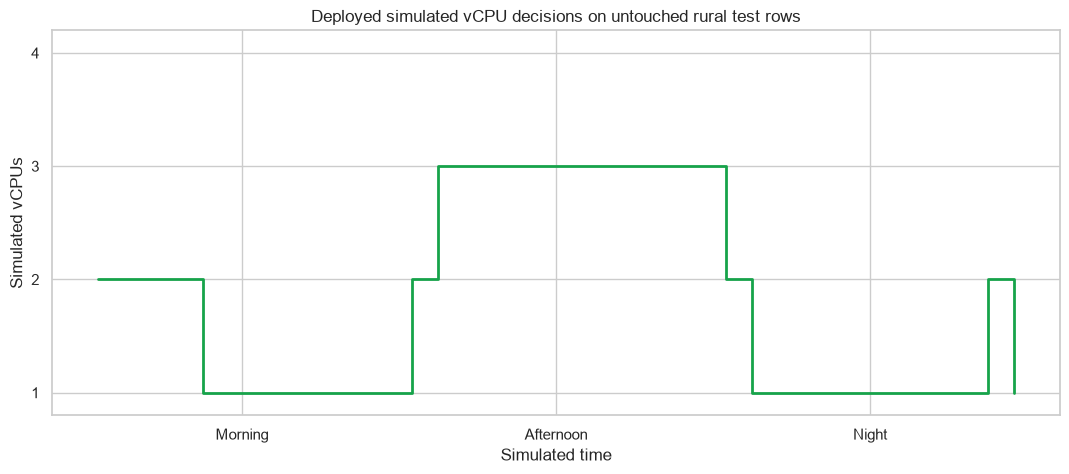

In [32]:
# Compare final reward, satisfaction, vCPU use and overload.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
policy_colours = ["#16a34a", "#6b7280", "#f59e0b"]

for axis, column, title, ylabel in [
    (axes[0, 0], "mean_reward", "Final rural test reward", "Mean episode reward"),
    (axes[0, 1], "mean_satisfaction", "Final service satisfaction", "Mean ratio"),
    (axes[1, 0], "mean_vcpu", "Final simulated vCPU use", "Mean vCPUs"),
    (axes[1, 1], "mean_overload_rate", "Final simulated overload", "Mean rate"),
]:
    axis.bar(
        final_test_summary["policy"],
        final_test_summary[column],
        color=policy_colours,
    )
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=12)

plt.savefig(FIGURE_DIR / "08_final_policy_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

# Run one natural-order trace for the deployed policy graph.
_, deployed_natural_trace = evaluate_one_episode(
    f"Deployed-{DEPLOYED_VERSION}",
    rural_splits["test"],
    seed=2026,
    model=deployed_model,
    start_offset=0,
)

plt.figure(figsize=(13, 5))
plt.step(
    np.arange(len(deployed_natural_trace)),
    deployed_natural_trace["vcpu"],
    where="post",
    color="#16a34a",
    linewidth=2,
)
plt.xticks([5.5, 17.5, 29.5], PHASES)
plt.yticks([1, 2, 3, 4])
plt.ylim(0.8, 4.2)
plt.title("Deployed simulated vCPU decisions on untouched rural test rows")
plt.xlabel("Simulated time")
plt.ylabel("Simulated vCPUs")
plt.savefig(FIGURE_DIR / "09_deployed_vcpu_trace.png", dpi=180, bbox_inches="tight")
plt.show()

## Save the Complete Evidence Record

In [33]:
# Save the measured data, decisions and results used by the final notebook.
hash_audit.to_csv(OUTPUT_DIR / "hash_audit.csv", index=False)
data_audit.to_csv(OUTPUT_DIR / "data_structure_audit.csv", index=False)
master_measured_data.to_csv(OUTPUT_DIR / "andm_master_measured_dataset.csv", index=False)
phase_summary.to_csv(OUTPUT_DIR / "measured_phase_summary.csv", index=False)
split_summary.to_csv(OUTPUT_DIR / "split_summary.csv", index=False)
simple_validation_summary.to_csv(OUTPUT_DIR / "simple_validation_summary.csv", index=False)
algorithm_runs.to_csv(OUTPUT_DIR / "algorithm_seed_results.csv", index=False)
algorithm_summary.to_csv(OUTPUT_DIR / "algorithm_summary.csv")
baseline_test_summary.to_csv(OUTPUT_DIR / "baseline_test_summary.csv", index=False)
adwin_calibration.to_csv(OUTPUT_DIR / "adwin_calibration.csv", index=False)
monitoring_trace.to_csv(OUTPUT_DIR / "monitoring_trace.csv", index=False)
drift_log.to_csv(OUTPUT_DIR / "drift_log.csv", index=False)
promotion_summary.to_csv(OUTPUT_DIR / "promotion_summary.csv", index=False)
promotion_plot.to_csv(OUTPUT_DIR / "promotion_validation_summary.csv", index=False)
final_test_episodes.to_csv(OUTPUT_DIR / "final_rural_test_episodes.csv", index=False)
final_test_summary.to_csv(OUTPUT_DIR / "final_rural_test_summary.csv", index=False)
deployed_natural_trace.to_csv(OUTPUT_DIR / "deployed_rural_trace.csv", index=False)

# Save the exact assumptions and important research boundaries.
experiment_record = {
    "package_versions": PACKAGE_VERSIONS,
    "final_mode": FINAL_MODE,
    "training_seeds": TRAINING_SEEDS,
    "evaluation_seeds": EVALUATION_SEEDS,
    "train_timesteps": TRAIN_TIMESTEPS,
    "adapt_timesteps": ADAPT_TIMESTEPS,
    "cpu_calibration_factor": CPU_CALIBRATION_FACTOR,
    "selected_algorithm": SELECTED_ALGORITHM,
    "selected_seed": BEST_SEED,
    "selection_basis": SELECTION_BASIS,
    "adwin_delta": ADWIN_DELTA,
    "drift_detected": DRIFT_DETECTED,
    "first_drift_index": FIRST_DRIFT_INDEX,
    "candidate_promoted": PROMOTE_CANDIDATE,
    "deployed_version": DEPLOYED_VERSION,
    "latency_timeout_rule": "NaN is preserved; 1000 ms is used only in model features.",
    "vcpu_boundary": "vCPU actions are simulated and are not physical Mininet CPU hot-plugging.",
    "evidence_boundary": "Measured ONOS-Mininet testbed inspired by ANDM; not operational ANDM telemetry.",
    "network_boundary": "The measured rural bottleneck cannot be fixed by adding vCPUs alone.",
}
with (OUTPUT_DIR / "experiment_record.json").open("w", encoding="utf-8") as file:
    json.dump(experiment_record, file, indent=2)

print(f"Saved evidence folder: {OUTPUT_DIR}")
print(f"Saved figures: {len(list(FIGURE_DIR.glob('*.png')))}")
print(f"Saved models: {len(list(MODEL_DIR.glob('*.zip')))}")

Saved evidence folder: C:\Users\Athenkosi Nqumako\OneDrive - University of Fort Hare\Desktop\Honours\Research\Mini-Dissertation\RL_Training\ANDM_Final_Measured_RL_Package\rl_outputs
Saved figures: 9
Saved models: 21
